In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [2]:
data = pd.read_csv('machine_temperature_system_failure.csv')

In [3]:
data.head(5)

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


<Axes: >

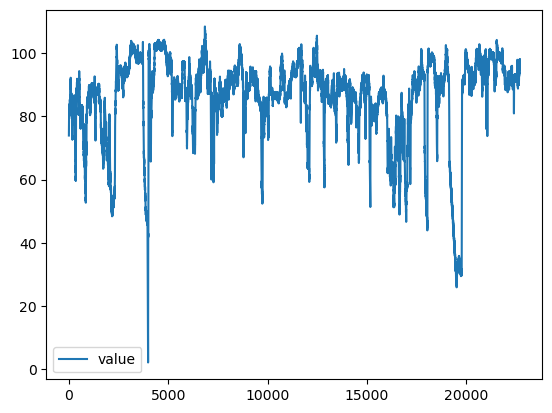

In [4]:
data.plot()

In [5]:
period = 288
data['rolling_mean'] = data.value.rolling(window=period).mean()
data['rolling_std'] = data.value.rolling(window=period).std()
data['z_scores'] = (data.value- data['rolling_mean']) / data['rolling_std']

In [6]:
data.dropna(inplace = True)

In [7]:
#Apply rolling Z-score: flag points > 3 std from the rolling mean
data['flag'] = data.apply(lambda x: True if abs(x['value'] - x['rolling_mean']) > 3 * x['rolling_std'] else False, axis=1)
data[data['flag'] == True]

,timestamp,value,rolling_mean,rolling_std,z_scores,flag
314,2013-12-03 23:25:00,70.080108,82.721739,4.134331,-3.057721,True
316,2013-12-03 23:35:00,69.411105,82.637887,4.264937,-3.101285,True
317,2013-12-03 23:40:00,68.237201,82.587544,4.348527,-3.300047,True
318,2013-12-03 23:45:00,68.810539,82.542708,4.423394,-3.104442,True
319,2013-12-03 23:50:00,67.951449,82.495448,4.505846,-3.227806,True
...,...,...,...,...,...,...
22399,2014-02-18 14:50:00,80.969539,91.619551,1.786991,-5.959746,True
22400,2014-02-18 14:55:00,82.222039,91.589647,1.870295,-5.008627,True
22401,2014-02-18 15:00:00,84.827809,91.573919,1.907801,-3.536067,True
22564,2014-02-19 04:35:00,97.452996,91.752733,1.899611,3.000753,True


In [8]:
data.index = data['timestamp']
data.drop(columns = ['timestamp'], inplace = True)

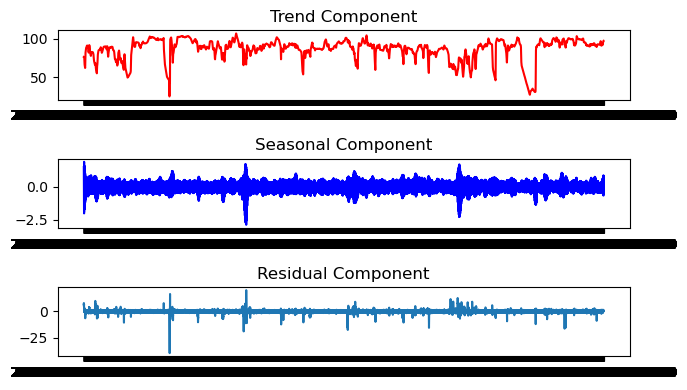

In [9]:
#Q2) Apply STL decomposition — flag residuals beyond a threshold
stl = STL(data['value'], period = 15, seasonal=13, robust=True) 
result = stl.fit()

# Plot the decomposition components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 4))

ax1.plot(data.index, result.trend, label='Trend', color='red')
ax1.set_title('Trend Component')
ax2.plot(data.index, result.seasonal, label='Seasonal', color='blue')
ax2.set_title('Seasonal Component')
ax3.plot(data.index, result.resid, label='Residual')
ax3.set_title('Residual Component')
plt.tight_layout()
plt.show()

In [10]:
data['residuals'] = result.resid

In [13]:
threshold = data['residuals'].std() * 3
data['residual_flag'] = data.apply(lambda x: True if abs(x['residuals']) > threshold else False, axis = 1)

In [14]:
data[data['residual_flag'] == True]

,value,rolling_mean,rolling_std,z_scores,flag,residuals,residual_flag
timestamp,,,,,,,
2013-12-03 21:10:00,83.453184,82.894559,3.797082,0.147120,False,5.810304,True
2013-12-03 21:15:00,84.332735,82.930550,3.761124,0.372810,False,7.058354,True
2013-12-03 21:20:00,83.624800,82.960720,3.731504,0.177966,False,6.855574,True
2013-12-03 21:25:00,83.820248,82.987443,3.709869,0.224484,False,7.912698,True
2013-12-03 21:30:00,82.821181,83.003694,3.698798,-0.049344,False,6.845627,True
...,...,...,...,...,...,...,...
2014-02-18 14:40:00,83.731850,91.681522,1.594064,-4.987046,True,-4.981491,True
2014-02-18 14:45:00,82.953906,91.656820,1.672353,-5.203993,True,-6.225158,True
2014-02-18 14:50:00,80.969539,91.619551,1.786991,-5.959746,True,-8.870511,True


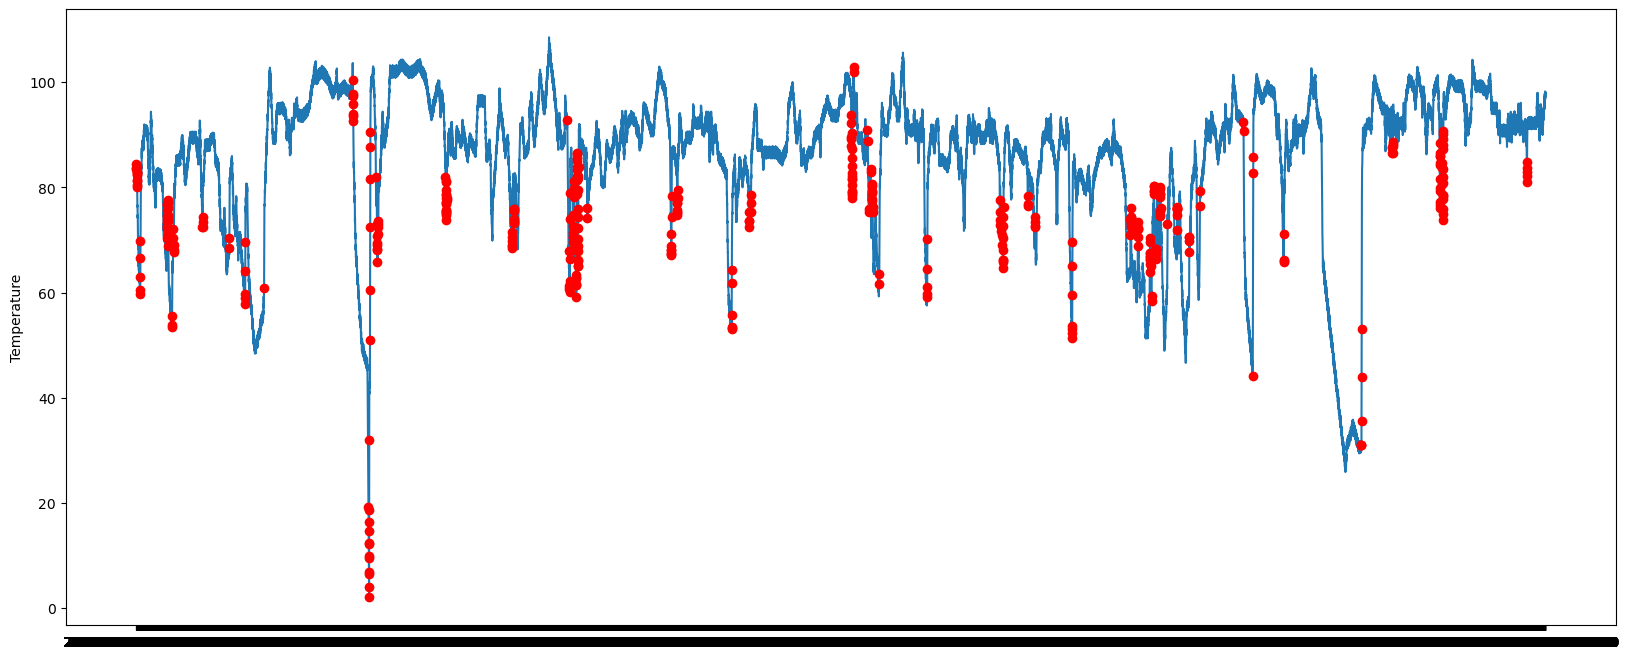

In [17]:
fig, ax1 = plt.subplots(1, sharex=True, figsize=(20, 8))
ax1.plot(data.index, data['value'], label='Temperature')
#ax1.plot(data[data['residual_flag'] == False].index, data[data['residual_flag'] == False], 'o', color='g', label='Normal Temp')
ax1.plot(data[data['residual_flag'] == True].index, data[data['residual_flag'] == True]['value'], 'o', color='r', label='Outlier')
ax1.set_ylabel('Temperature')
plt.show()